In [1]:
import pandas as pd
import numpy as np
import networkx as nx

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

In [2]:
os.getcwd()

'd:\\01_project\\2602-GNN\\notebooks'

In [3]:
PROJECT_ROOT = r'd:\01_project\2602-GNN'
DATA_DIR = os.path.join(PROJECT_ROOT, 'data', 'elliptic_bitcoin_dataset') 

# Load & merge data

In [4]:
# 节点（标签）、边、时间步（特征）df格式
df_classes = pd.read_csv(DATA_DIR + '\\elliptic_txs_classes.csv', index_col='txId')
df_edges = pd.read_csv(DATA_DIR + '\\elliptic_txs_edgelist.csv')
df_features = pd.read_csv(DATA_DIR + '\\elliptic_txs_features.csv',header=None)

In [5]:
# 把特征csv的第2列改为时间步time_step,后面特征顺序排列1-166
feature_columns =['txId','time_step']+[f'feature_{i}' for i in range(1,166)]
df_features.columns = feature_columns

In [6]:
print("df_classes 的形状和索引示例:")
print(f"Shape: {df_classes.shape}")
print(f"前5个索引: {df_classes.index[:5].tolist()}")
print(f"class列唯一值: {df_classes['class'].unique()}")

print("df_features 的形状和索引示例:")
print(f"Shape: {df_features.shape}")
print(f"前5个索引: {df_features.index[:5].tolist()}")
print(f"索引类型: {type(df_features.index[0])}")

df_classes 的形状和索引示例:
Shape: (203769, 1)
前5个索引: [230425980, 5530458, 232022460, 232438397, 230460314]
class列唯一值: <StringArray>
['unknown', '2', '1']
Length: 3, dtype: str
df_features 的形状和索引示例:
Shape: (203769, 167)
前5个索引: [0, 1, 2, 3, 4]
索引类型: <class 'int'>


In [7]:
# merge1: 特征和节点（标签）
df_features = df_features.set_index('txId')
df_features.index = df_features.index.astype(str)
df_classes.index = df_classes.index.astype(str)

df_nodes = df_features.merge(df_classes, left_index=True, right_index=True, how='left') # 保留完整的图特征
df_nodes['class'] = df_nodes['class'].replace({'unknown': '3'}).astype(int)

In [8]:
class_counts = df_nodes['class'].value_counts().sort_index()
print(class_counts)

class
1      4545
2     42019
3    157205
Name: count, dtype: int64


In [9]:
df_edges.head()
# txId1是输出，2是输入

,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


In [10]:
# merge2: 边中输出对应的交易时间步——根据交易发起作为时间戳
df_edges_renamed = df_edges.rename(columns={'txId1': 'Source', 'txId2': 'Target'}).astype(str)
df_edges_temporal = df_edges_renamed.merge(
    df_nodes['time_step'],
    left_on='Source',
    right_index=True,
    how='left'
).rename(columns={'time_step': 'time_step_edge'})
# ！需要drop掉无时间步的边，本身图稀疏，后续进行动态时序分析必要
df_edges_temporal = df_edges_temporal[df_edges_temporal['time_step_edge'] != -1]

In [11]:
df_edges_temporal['time_step_edge'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])

# Dynamic temporal analysis

1. 非法交易在网络中的影响力（PageRank）如何随时间变化？
2. 是否存在特定的时间窗口，非法交易活动更活跃？
3. 网络中心性指标能否作为欺诈检测的特征？
- 分析网络结构如何随时间变化，并对比非法与合法交易在图模式上的差异
- 输出：df_temporal_metrics表格，记录每个节点在不同时刻的类别、PageRank值和入度。

## 1 2采样优化-PageRank计算复杂度为O(I×E)

In [12]:
# 每隔5个时间步采样，提高计算效率
TIME_STEPS = [int(t) for t in df_edges_temporal['time_step_edge'].unique()]
TIME_STEPS.sort()   # .sort()是原地排序，返回none
ANALYSIS_STEPS = TIME_STEPS[::5]
print(f'样本{len(ANALYSIS_STEPS)} 个 用于后续动态时间分析: {ANALYSIS_STEPS}')

样本10 个 用于后续动态时间分析: [1, 6, 11, 16, 21, 26, 31, 36, 41, 46]


In [13]:
# 边采样，取0.6
SAMPLING_RATE = 0.6
# 取采样边list
df_edges_sampled = df_edges_temporal.sample(frac=SAMPLING_RATE, random_state=42)
print(f'样本边: {df_edges_sampled.shape[0]}')

样本边: 140613


## 2 构建瞬时图+PageRank+in_degree计算

- 时序图快照构建​ - 从连续时序数据中提取离散时间点图
- NetworkX图操作​ - 创建、操作、分析图结构
- 中心性度量计算​ - 量化节点在网络中的重要性——pr和in_de两者结合=全局+局部
- 属性图构建​ - 为节点添加元数据（标签）

- 同时计算PageRank和入度？
- 衡量节点“重要性”的不同维度，在风控中有不同含义。
- 入度 (In-Degree)：局部、直接的度量。一个节点的入度就是直接指向它的交易数量。在比特币网络中，高入度地址可能是一个“资金汇集地址”（如交易所热钱包）
- PageRank：全局、递归的度量。它不仅看有多少交易指向，还看指向那些交易本身是否重要。
- 一个节点可能入度不高，但如果连入它的几个节点本身是网络中的关键枢纽（高PageRank节点），那么这个节点的PageRank也会很高。它捕捉的是资金流动路径中的“影响力”传递。在洗钱链条中，一个关键的“中转账户”可能就具有这种特征。
- 实践意义：在风控场景，单纯的“收款多”（高入度）不一定是非法。
但一个处于资金流通关键路径、连接多个非法子网络（高PageRank）的地址，风险极高。同时计算二者，可以构建更丰富的特征，或交叉验证可疑模式。

- 中心性多种，根据计算效率，前期使用pr和入度

In [14]:
temporal_results = []
IME_STEP_COLUMN_NAME = 'time_step'

print(f"\n开始进行采样数据的时序快照分析 {len(ANALYSIS_STEPS)}")

for t in ANALYSIS_STEPS:
    print(f'—— 处理时间步{t}')
    # 1 每个采样时间步中采样后的边
    current_edges = df_edges_sampled[df_edges_sampled['time_step_edge'] == t]
    # 2 构建有向图G_t
    G_t = nx.from_pandas_edgelist(
        current_edges, 
        source='Source', 
        target='Target', 
        create_using=nx.DiGraph()
    )
    # 3 增加交易类型属性class作为标签label
    snapshot_node_ids = set(G_t.nodes())
    snapshot_nodes_data = df_nodes[df_nodes.index.isin(snapshot_node_ids)]  # 获取采样的节点
    node_labels = snapshot_nodes_data['class'].to_dict()
    nx.set_node_attributes(G_t, node_labels, 'label')
    # 4 中心性计算,try防止空图
    try:
        pr_scores = nx.pagerank(G_t) 
        in_degree = dict(G_t.in_degree())   # G_t.in_degree()返回的是一个DegreeView可迭代对象，与pr对齐，转为dict
    except nx.NetworkXError:
        pr_scores = {}
        in_degree = {}
    # 5 保存结果
    for node_id in snapshot_node_ids:
        if node_id in node_labels: 
            temporal_results.append({
                'Time_Step': t,
                'Node_ID': node_id,
                'PageRank': pr_scores.get(node_id, 0),
                'In_Degree': in_degree.get(node_id, 0),
                'Class': node_labels[node_id]
            })  # get[]如果缺失键会error，使用get(key,default)无则返回默认步报错，0不在dict里面，没有影响力
df_temporal_metrics = pd.DataFrame(temporal_results)
print('构建图和计算完成')
print(f'共完成: {df_temporal_metrics.shape[0]}交易记录')


开始进行采样数据的时序快照分析 10
—— 处理时间步1
—— 处理时间步6
—— 处理时间步11
—— 处理时间步16
—— 处理时间步21
—— 处理时间步26
—— 处理时间步31
—— 处理时间步36
—— 处理时间步41
—— 处理时间步46
构建图和计算完成
共完成: 34159交易记录


In [15]:
df_temporal_metrics

,Time_Step,Node_ID,PageRank,In_Degree,Class
0,1,3881050,0.000196,1,2
1,1,96624513,0.000076,0,3
2,1,2920819,0.000076,0,2
3,1,230537117,0.001508,17,3
4,1,232066991,0.000136,1,3
...,...,...,...,...,...
34154,46,196090661,0.000371,1,3
34155,46,52457502,0.000322,1,3
34156,46,194341955,0.000200,0,3
34157,46,6470106,0.000371,1,3


In [16]:
df_temporal_metrics.describe()

,Time_Step,PageRank,In_Degree,Class
count,34159.000000,34159.000000,34159.000000,34159.000000
mean,21.924500,0.000293,0.875465,2.775462
std,15.700418,0.000474,2.777754,0.452879
min,1.000000,0.000076,0.000000,1.000000
25%,6.000000,0.000136,0.000000,3.000000
50%,21.000000,0.000214,1.000000,3.000000
75%,36.000000,0.000331,1.000000,3.000000
max,46.000000,0.023869,123.000000,3.000000


入度极度不平衡（少数节点拥有绝大多数连接）
稀疏但有关键枢纽
存在明显异常值（入度=123的节点）

# Visualize*2

- 群体差异：非法交易作为一个整体，其网络影响力（PageRank）与合法交易相比有何不同？这种差异是否随时间变化？
- 个体追踪：整个网络中，最具影响力的单个节点是谁？它的影响力轨迹如何？

## 1 非法与否平均PageRank时序对比

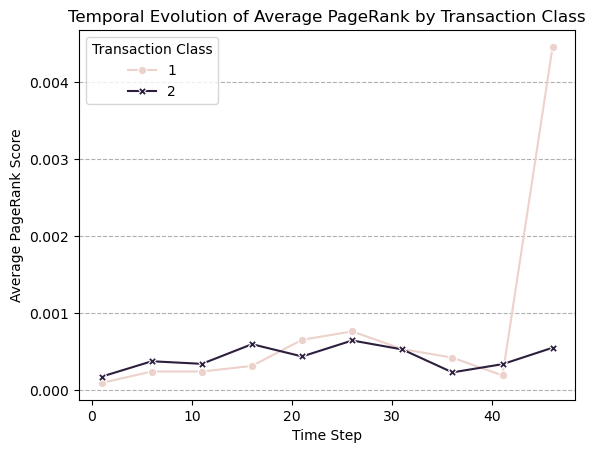

In [17]:
# 1 分组，每个时间步下的每类（列）的pr均值
df_plot = df_temporal_metrics.groupby(['Time_Step', 'Class'])['PageRank'].mean().reset_index()
# 2 取已知的两类作为标签
df_plot_labeled = df_plot[df_plot['Class'] != 3]

# 绘制两类的时序折线图
sns.lineplot(
        data=df_plot_labeled, 
        x='Time_Step', 
        y='PageRank', 
        hue='Class',
        style='Class', 
        markers=True,
        dashes=False
    )

plt.legend(title='Transaction Class')
plt.title('Temporal Evolution of Average PageRank by Transaction Class', fontsize=12)
plt.xlabel('Time Step', fontsize=10)
plt.ylabel('Average PageRank Score', fontsize=10)
plt.grid(axis='y', linestyle='--')
plt.show()

欺诈的在最后的时间步的pr异常高

## 2 欺诈在某时间步最高pr的节点追踪时序

In [18]:
# sort排倒序pr，iloc[0]取全局最大值
df_top_node = df_temporal_metrics.sort_values(by='PageRank', ascending=False).iloc[0]
# 打印查看最高pr的ID，类别是否欺诈（证明的确图相关）和pr值
top_node_id = df_top_node['Node_ID']
top_node_class = df_top_node['Class']
print(f"\n影响力最高的节点ID：{top_node_id}, 类别: {top_node_class}, PageRank最大值: {df_top_node['PageRank']:.6f}")


影响力最高的节点ID：196107869, 类别: 2, PageRank最大值: 0.023869


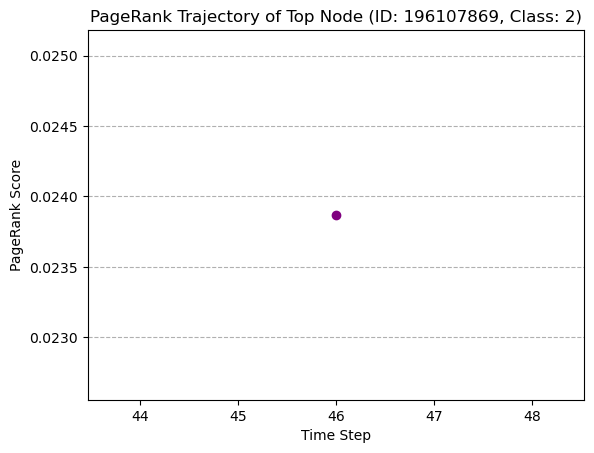

In [19]:
df_node_trajectory = df_temporal_metrics[df_temporal_metrics['Node_ID'] == top_node_id]

#plt.figure(figsize=(10, 4))
plt.plot(df_node_trajectory['Time_Step'], df_node_trajectory['PageRank'], marker='o', linestyle='-', color='purple')
plt.title(f"PageRank Trajectory of Top Node (ID: {top_node_id}, Class: {top_node_class})", fontsize=12)
plt.xlabel('Time Step', fontsize=10)
plt.ylabel('PageRank Score', fontsize=10)
plt.grid(axis='y', linestyle='--')
plt.show()

In [20]:
import pickle
with open('df_temporal_metrics_sampled.pkl', 'wb') as f:
    pickle.dump(df_temporal_metrics, f)

- “欺诈群体在45后平均PR更高”：这意味着在某个时间段（例如一次有组织的攻击或洗钱活动期间），大量非法交易节点集体​ 表现出了网络影响力的提升。它们可能互相连接，形成一个“团伙”，从而拉高了整个群体的平均PR。这是一个群体性、隐蔽性的信号。
- “全局最高PR节点是合法的”：这反映了一个基本事实：在金融网络中，最核心、连接最多的枢纽节点，往往是大型、合规的机构（如交易所、托管银行）。它们的业务量巨大，自然处于网络的中心。这是一个个体性、体量性的特征。

欺诈交易在图结构上，并非表现为单一的、突出的核心节点，而是表现为一种隐蔽的、动态的、集体性的异常模式

- 群体统计对比：欺诈 vs. 合法群体，在整体分布上是否有差异？
- 内部结构对比：在各自群体内部，节点的重要性结构有何不同？
- 动态行为对比：节点的影响力是如何随时间演变的？是否存在爆发式增长？
- 关联模式对比：欺诈交易之间的局部连接模式是否异常？

# *Graph EDA

## 全量数据

In [21]:
# 将采样率设为1.0
SAMPLING_RATE = 1.0
# 选择分析全部时间步
TIME_STEPS = [int(t) for t in df_edges_temporal['time_step_edge'].unique()]
TIME_STEPS.sort()
ANALYSIS_STEPS = TIME_STEPS

df_edges_all = df_edges_temporal.copy()

In [22]:
temporal_results = []
IME_STEP_COLUMN_NAME = 'time_step'

print(f"\n开始进行全量数据的时序快照分析 {len(ANALYSIS_STEPS)}")

for t in ANALYSIS_STEPS:
    print(f'—— 处理时间步{t}')
    # 1 每个采样时间步中采样后的边
    current_edges = df_edges_all[df_edges_all['time_step_edge'] == t]
    # 2 构建有向图G_t
    G_t = nx.from_pandas_edgelist(
        current_edges, 
        source='Source', 
        target='Target', 
        create_using=nx.DiGraph()
    )
    # 3 增加交易类型属性class作为标签label
    snapshot_node_ids = set(G_t.nodes())
    snapshot_nodes_data = df_nodes[df_nodes.index.isin(snapshot_node_ids)]  # 获取采样的节点
    node_labels = snapshot_nodes_data['class'].to_dict()
    nx.set_node_attributes(G_t, node_labels, 'label')
    # 4 中心性计算,try防止空图
    try:
        pr_scores = nx.pagerank(G_t) 
        in_degree = dict(G_t.in_degree())   # G_t.in_degree()返回的是一个DegreeView可迭代对象，与pr对齐，转为dict
    except nx.NetworkXError:
        pr_scores = {}
        in_degree = {}
    # 5 保存结果
    for node_id in snapshot_node_ids:
        if node_id in node_labels: 
            temporal_results.append({
                'Time_Step': t,
                'Node_ID': node_id,
                'PageRank': pr_scores.get(node_id, 0),
                'In_Degree': in_degree.get(node_id, 0),
                'Class': node_labels[node_id]
            })  # get[]如果缺失键会error，使用get(key,default)无则返回默认步报错，0不在dict里面，没有影响力
df_temporal_metrics = pd.DataFrame(temporal_results)
print('构建图和计算完成')
print(f'共完成: {df_temporal_metrics.shape[0]}交易记录')


开始进行全量数据的时序快照分析 49
—— 处理时间步1
—— 处理时间步2
—— 处理时间步3
—— 处理时间步4
—— 处理时间步5
—— 处理时间步6
—— 处理时间步7
—— 处理时间步8
—— 处理时间步9
—— 处理时间步10
—— 处理时间步11
—— 处理时间步12
—— 处理时间步13
—— 处理时间步14
—— 处理时间步15
—— 处理时间步16
—— 处理时间步17
—— 处理时间步18
—— 处理时间步19
—— 处理时间步20
—— 处理时间步21
—— 处理时间步22
—— 处理时间步23
—— 处理时间步24
—— 处理时间步25
—— 处理时间步26
—— 处理时间步27
—— 处理时间步28
—— 处理时间步29
—— 处理时间步30
—— 处理时间步31
—— 处理时间步32
—— 处理时间步33
—— 处理时间步34
—— 处理时间步35
—— 处理时间步36
—— 处理时间步37
—— 处理时间步38
—— 处理时间步39
—— 处理时间步40
—— 处理时间步41
—— 处理时间步42
—— 处理时间步43
—— 处理时间步44
—— 处理时间步45
—— 处理时间步46
—— 处理时间步47
—— 处理时间步48
—— 处理时间步49
构建图和计算完成
共完成: 203769交易记录


## 1 群体统计对比：集中、离散、分布

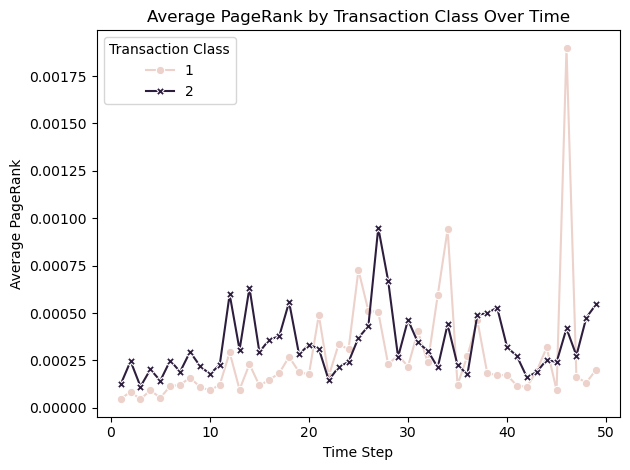

In [23]:
# 1. 数据聚合：计算每个时间步、每个类别的平均PageRank
df_plot = df_temporal_metrics.groupby(['Time_Step', 'Class'], as_index=False)['PageRank'].mean()

# 2. 过滤掉未知类别，比较Illicit和Licit
df_plot_labeled = df_plot[df_plot['Class'] != 3]

# 3. 绘制趋势对比图
sns.lineplot(data=df_plot_labeled,
             x='Time_Step',
             y='PageRank',
             hue='Class',
             style='Class',
             markers=True,
             dashes=False)

plt.title('Average PageRank by Transaction Class Over Time', fontsize=12)
plt.xlabel('Time Step')
plt.ylabel('Average PageRank')
plt.legend(title='Transaction Class')
plt.tight_layout()
plt.show()

结果：时间步46异常高pr欺诈；方向：深度分析ts46的欺诈节点变化

## 2 ts46内部结构

大部分欺诈的pr普遍提升，还是少数欺诈pr拉动

- ts46下，欺诈与非欺诈 节点PageRank的并排箱线图。
预期结论：
- A. 若欺诈箱体整体上移、中位数更高，说明是群体性抬高，欺诈节点普遍在此时更有影响力。
- B. 若欺诈箱体位置相似但存在大量上侧异常点，说明是少数极端值拉动。

In [24]:
df_temporal_metrics.describe()

,Time_Step,PageRank,In_Degree,Class
count,203769.000000,203769.000000,203769.000000,203769.000000
mean,23.843961,0.000240,1.150101,2.749182
std,15.172170,0.000463,3.911132,0.482202
min,1.000000,0.000036,0.000000,1.000000
25%,9.000000,0.000086,0.000000,3.000000
50%,23.000000,0.000146,1.000000,3.000000
75%,38.000000,0.000264,1.000000,3.000000
max,49.000000,0.026554,284.000000,3.000000


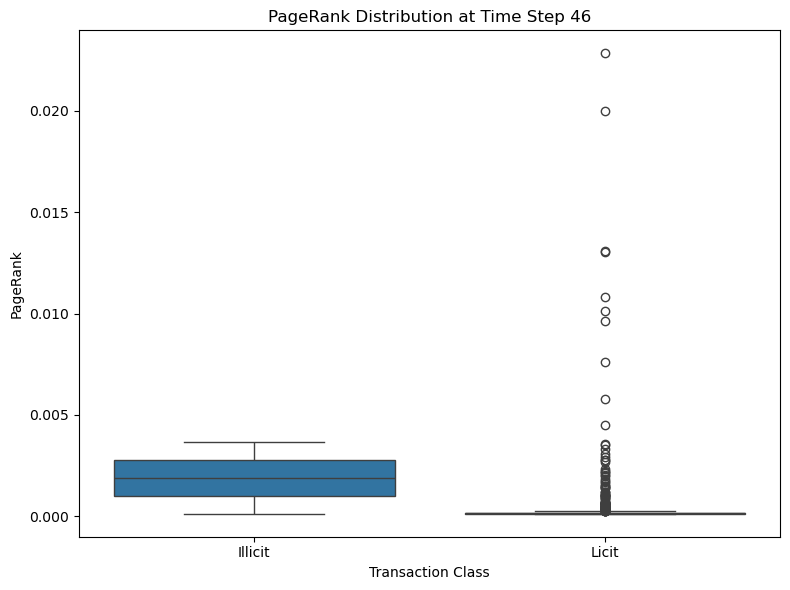

Illicit PageRank statistics:
count    2.000000
mean     0.001898
std      0.002503
min      0.000128
25%      0.001013
50%      0.001898
75%      0.002783
max      0.003668
Name: PageRank, dtype: float64

Licit PageRank statistics:
count    710.000000
mean       0.000418
std        0.001561
min        0.000128
25%        0.000128
50%        0.000140
75%        0.000180
max        0.022830
Name: PageRank, dtype: float64


In [25]:
# 提取时间步46的数据
df_step_46 = df_temporal_metrics[df_temporal_metrics['Time_Step'] == 46]

# 绘制箱线图
plt.figure(figsize=(8, 6))
sns.boxplot(x='Class', y='PageRank', data=df_step_46, order=[1, 2])
plt.title('PageRank Distribution at Time Step 46')
plt.xlabel('Transaction Class')
plt.ylabel('PageRank')
plt.xticks([0, 1], ['Illicit', 'Licit'])

plt.tight_layout()
plt.show()

# 输出基本统计量
print("Illicit PageRank statistics:")
print(df_step_46[df_step_46['Class'] == 1]['PageRank'].describe())
print("\nLicit PageRank statistics:")
print(df_step_46[df_step_46['Class'] == 2]['PageRank'].describe())

结果：合法交易长尾，极少高pr枢纽；少量高影响力欺诈节点

## 3 异常变化对比：ts46是否显著

假如2分析结果欺诈节点具有一定规模：时间窗口46±1的群体变化率模式

实际上一步结果：追踪那2个具体的Illicit节点和1个极端的Licit枢纽节点

In [26]:
# 1. 识别时间步46的两个Illicit节点
illicit_nodes_step46 = df_step_46[df_step_46['Class'] == 1]['Node_ID'].tolist()
print(f"Time Step 46 Illicit Node IDs: {illicit_nodes_step46}")

# 2. 识别时间步46 PageRank最高的Licit节点
top_licit_node_step46 = df_step_46[df_step_46['Class'] == 2].nlargest(1, 'PageRank').iloc[0]['Node_ID'] # nlargest 按 PageRank 列降序排列，取排名前 N=1 行；iloc[0]转为series键值对
print(f"Time Step 46 Top Licit Node ID: {top_licit_node_step46}")

Time Step 46 Illicit Node IDs: ['75078587', '196122645']
Time Step 46 Top Licit Node ID: 196107869


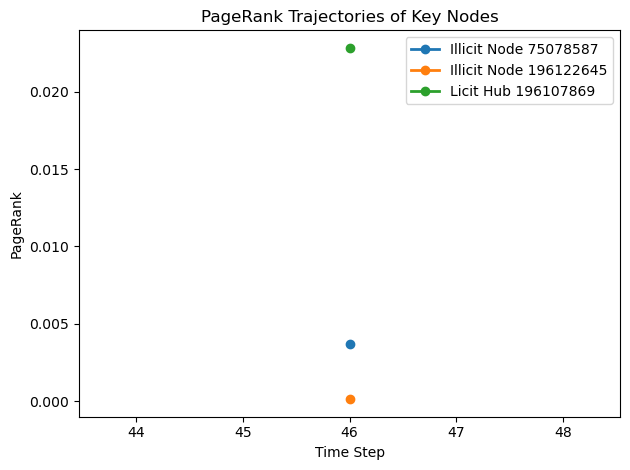

In [27]:
# 3. 提取这三个节点的完整历史轨迹
key_nodes = illicit_nodes_step46 + [top_licit_node_step46]  # 单值合法ID非列表
df_key_trajectories = df_temporal_metrics[df_temporal_metrics['Node_ID'].isin(key_nodes)]

# 4. 绘制PageRank时间序列对比图
#plt.figure(figsize=(12, 6))
for node_id in key_nodes:
    node_data = df_key_trajectories[df_key_trajectories['Node_ID'] == node_id]
    label = f'Illicit Node {node_id}' if node_id in illicit_nodes_step46 else f'Licit Hub {node_id}'
    plt.plot(node_data['Time_Step'], node_data['PageRank'], marker='o', label=label, linewidth=2)


plt.title('PageRank Trajectories of Key Nodes', fontsize=12)
plt.xlabel('Time Step')
plt.ylabel('PageRank')
plt.legend()

plt.tight_layout()
plt.show()

结果：关键欺诈节点的影响力爆发是“瞬时”的，而非持续的，并没有在时序上有发现，下一步关心局部网络结构。度和一阶邻居

## 4 局部聚类/局部结构in_degree+邻居节点pr

- 入度验证：检查关键节点在时间步46的入度是否异常
- 邻居画像：入边邻居的类别分布

In [ ]:
# 1. 入度分析 - 验证高PageRank的来源
# 直接使用从图中确认的关键节点ID
key_node_ids = ['196122645','75078587', '196107869']

# 从完整数据中筛选出这些节点在时间步46的记录
step_46_data = df_temporal_metrics[df_temporal_metrics['Time_Step'] == 46]
in_degree_df = step_46_data[step_46_data['Node_ID'].isin(key_node_ids)].copy()

# 排序并展示
in_degree_df = in_degree_df.sort_values('PageRank', ascending=False)
print("In-Degree Analysis for Key Nodes at Time Step 46:")
print(in_degree_df[['Node_ID', 'Class', 'PageRank', 'In_Degree']].to_string(index=False))

# 计算PageRank与入度的相关性（基于这3个点实际并无必要
if len(in_degree_df) >= 2:
    correlation = in_degree_df['PageRank'].corr(in_degree_df['In_Degree'])
    print(f"\nCorrelation (PageRank vs. In-Degree): {correlation:.3f}")

In-Degree Analysis for Key Nodes at Time Step 46:
  Node_ID  Class  PageRank  In_Degree
196107869      2  0.022830        188
 75078587      1  0.003668         45
196122645      1  0.000128          0

Correlation (PageRank vs. In-Degree): 0.996


In [30]:
step_46_data.columns

Index(['Time_Step', 'Node_ID', 'PageRank', 'In_Degree', 'Class'], dtype='str')

结果：欺诈的两个节点分别是两种情况，入度和pr双高，入读和pr双低
- 解释：一个为欺诈资金汇集点，另一个为资金分发点、中转站/孤立点？

优化：前面PageRank数学本质+业务场景假设资金汇集，更加关注入度，现在可以增加出度的计算

In [31]:
# 综合度分析 - 分析节点在资金流中的角色 (入度+出度)
key_node_ids = ['196122645', '75078587', '196107869']

# 1. 从 df_temporal_metrics 获取入度 (已存在) 和 PageRank
step_46_data = df_temporal_metrics[df_temporal_metrics['Time_Step'] == 46]
node_metrics = step_46_data[step_46_data['Node_ID'].isin(key_node_ids)].copy()

# 2. 计算每个节点的出度 (需从原始边列表动态计算)
# 获取时间步46的所有边
edges_46 = df_edges_temporal[df_edges_temporal['time_step_edge'] == 46]

# 为每个关键节点计算出度
out_degree_list = []
for node_id in key_node_ids:
    # 出度 = 该节点作为 'Source' 的边的数量
    out_deg = len(edges_46[edges_46['Source'] == node_id])
    out_degree_list.append(out_deg)

# 将出度添加到分析表中
node_metrics['Out_Degree'] = out_degree_list

# 重新排序并展示
node_metrics = node_metrics.sort_values('PageRank', ascending=False)
print("Degree Analysis for Key Nodes at Time Step 46:")
print(node_metrics[['Node_ID', 'Class', 'PageRank', 'In_Degree', 'Out_Degree']].to_string(index=False))


Degree Analysis for Key Nodes at Time Step 46:
  Node_ID  Class  PageRank  In_Degree  Out_Degree
196107869      2  0.022830        188           0
 75078587      1  0.003668         45           1
196122645      1  0.000128          0           0


### BUG-错误赋值导致后续检查无出入度的欺诈节点，out_degree_list排序根据列表索引，但node_metrics经过了排序筛选，两者不一致！

In [32]:
# 检查节点196122645在时间步46是否有自环
node_id = '196122645'
time_step = 46

# 从边数据中查找
self_loop = df_edges_temporal[
    (df_edges_temporal['time_step_edge'] == time_step) & 
    (df_edges_temporal['Source'] == node_id) & 
    (df_edges_temporal['Target'] == node_id)
]

if not self_loop.empty:
    print(f"发现自环: {len(self_loop)} 条")
else:
    print("没有发现自环")

没有发现自环


In [35]:
# 获取时间步46的边数据，构建有向图
edges_46 = df_edges_temporal[df_edges_temporal['time_step_edge'] == 46]
G_46 = nx.from_pandas_edgelist(edges_46, source='Source', target='Target', create_using=nx.DiGraph())

# 计算悬挂节点（出度为0的节点）的数量和比例
dangling_nodes = [node for node in G_46.nodes() if G_46.out_degree(node) == 0]
total_nodes = G_46.number_of_nodes()

print(f"时间步46的图结构：")
print(f"  总节点数: {total_nodes}")
print(f"  悬挂节点数: {len(dangling_nodes)}")
print(f"  悬挂节点比例: {len(dangling_nodes)/total_nodes:.2%}")

# 检查节点196122645的出度（应为0）
if '196122645' in G_46.nodes():
    print(f"\n节点196122645的出度: {G_46.out_degree('196122645')}")
else:
    print(f"\n节点196122645不在图G_46的节点集中（说明它在df_temporal_metrics中，但不在当前边数据构建的图中）。")

时间步46的图结构：
  总节点数: 3519
  悬挂节点数: 924
  悬挂节点比例: 26.26%

节点196122645的出度: 1


In [38]:
node_id = '196122645'
t = 46

# 方法A: 从边表切片直接查询
edges_at_t = df_edges_temporal[df_edges_temporal['time_step_edge'] == t]
direct_out = edges_at_t[edges_at_t['Source'] == node_id]
direct_in = edges_at_t[edges_at_t['Target'] == node_id]

print(f"【直接查询边表】时间步{t}，节点{node_id}:")
print(f"  作为起点的边数(出度): {len(direct_out)}")
print(f"  作为终点的边数(入度): {len(direct_in)}")

# 方法B: 从df_temporal_metrics中查询
record_in_metrics = df_temporal_metrics[(df_temporal_metrics['Time_Step'] == t) & (df_temporal_metrics['Node_ID'] == node_id)]
if not record_in_metrics.empty:
    print(f"\n【查询df_temporal_metrics】时间步{t}，节点{node_id}:")
    print(f"  记录到的入度(In_Degree): {record_in_metrics.iloc[0]['In_Degree']}")
    # df_temporal_metrics 中没有存储出度，所以这里无法对比
else:
    print(f"\n【警告】在df_temporal_metrics中未找到时间步{t}的节点{node_id}记录")

【直接查询边表】时间步46，节点196122645:
  作为起点的边数(出度): 1
  作为终点的边数(入度): 0

【查询df_temporal_metrics】时间步46，节点196122645:
  记录到的入度(In_Degree): 0


### debug

In [39]:
# 综合度分析 - 分析节点在资金流中的角色 (入度+出度)
key_node_ids = ['196122645', '75078587', '196107869']

# 1. 从 df_temporal_metrics 获取入度 (已存在) 和 PageRank
step_46_data = df_temporal_metrics[df_temporal_metrics['Time_Step'] == 46]
node_metrics = step_46_data[step_46_data['Node_ID'].isin(key_node_ids)].copy()

# 2. 计算每个节点的出度
edges_46 = df_edges_temporal[df_edges_temporal['time_step_edge'] == 46]

# 确保node_metrics按key_node_ids的顺序排列
node_metrics = node_metrics.set_index('Node_ID').loc[key_node_ids].reset_index()

# 按相同顺序计算出度
out_degree_list = []
for node_id in key_node_ids:
    out_deg = len(edges_46[edges_46['Source'] == node_id])
    out_degree_list.append(out_deg)

node_metrics['Out_Degree'] = out_degree_list

In [40]:
node_metrics

,Node_ID,Time_Step,PageRank,In_Degree,Class,Out_Degree
0,196122645,46,0.000128,0,1,1
1,75078587,46,0.003668,45,1,0
2,196107869,46,0.022830,188,2,0


In [41]:
# 邻居类别分析 - 分析关键节点的资金流向和来源风险
key_node_ids = ['196122645', '75078587', '196107869']

# 获取时间步46的边数据
edges_46 = df_edges_temporal[df_edges_temporal['time_step_edge'] == 46]

# 准备结果存储
neighbor_analysis_results = []

for node_id in key_node_ids:
    # 获取节点基本信息
    node_info = df_temporal_metrics[
        (df_temporal_metrics['Time_Step'] == 46) & 
        (df_temporal_metrics['Node_ID'] == node_id)
    ]
    
    if node_info.empty:
        continue
    
    node_class = node_info.iloc[0]['Class']
    
    # 1. 分析入边邻居 (资金来源)
    in_neighbors = edges_46[edges_46['Target'] == node_id]['Source'].tolist()
    
    # 统计入边邻居类别
    in_class_counts = {'Illicit': 0, 'Licit': 0, 'Unknown': 0, 'No_Label': 0}
    in_neighbor_details = []
    
    for neighbor_id in in_neighbors:
        # 尝试在df_nodes中查找邻居类别
        if neighbor_id in df_nodes.index:
            neighbor_class = df_nodes.loc[neighbor_id, 'class']
            if neighbor_class == '1' or neighbor_class == 1:
                in_class_counts['Illicit'] += 1
            elif neighbor_class == '2' or neighbor_class == 2:
                in_class_counts['Licit'] += 1
            elif neighbor_class == '3' or neighbor_class == 3 or neighbor_class == 'unknown':
                in_class_counts['Unknown'] += 1
            else:
                in_class_counts['No_Label'] += 1
        else:
            in_class_counts['No_Label'] += 1
    
    # 2. 分析出边邻居 (资金去向)
    out_neighbors = edges_46[edges_46['Source'] == node_id]['Target'].tolist()
    
    # 统计出边邻居类别
    out_class_counts = {'Illicit': 0, 'Licit': 0, 'Unknown': 0, 'No_Label': 0}
    out_neighbor_details = []
    
    for neighbor_id in out_neighbors:
        # 尝试在df_nodes中查找邻居类别
        if neighbor_id in df_nodes.index:
            neighbor_class = df_nodes.loc[neighbor_id, 'class']
            if neighbor_class == '1' or neighbor_class == 1:
                out_class_counts['Illicit'] += 1
            elif neighbor_class == '2' or neighbor_class == 2:
                out_class_counts['Licit'] += 1
            elif neighbor_class == '3' or neighbor_class == 3 or neighbor_class == 'unknown':
                out_class_counts['Unknown'] += 1
            else:
                out_class_counts['No_Label'] += 1
        else:
            out_class_counts['No_Label'] += 1
    
    # 计算比例
    total_in = len(in_neighbors)
    total_out = len(out_neighbors)
    
    in_illicit_ratio = in_class_counts['Illicit'] / total_in if total_in > 0 else 0
    in_licit_ratio = in_class_counts['Licit'] / total_in if total_in > 0 else 0
    
    out_illicit_ratio = out_class_counts['Illicit'] / total_out if total_out > 0 else 0
    out_licit_ratio = out_class_counts['Licit'] / total_out if total_out > 0 else 0
    
    # 存储结果
    neighbor_analysis_results.append({
        'Node_ID': node_id,
        'Class': node_class,
        'Total_In_Neighbors': total_in,
        'In_Illicit_Count': in_class_counts['Illicit'],
        'In_Illicit_Ratio': in_illicit_ratio,
        'In_Licit_Count': in_class_counts['Licit'],
        'In_Licit_Ratio': in_licit_ratio,
        'Total_Out_Neighbors': total_out,
        'Out_Illicit_Count': out_class_counts['Illicit'],
        'Out_Illicit_Ratio': out_illicit_ratio,
        'Out_Licit_Count': out_class_counts['Licit'],
        'Out_Licit_Ratio': out_licit_ratio
    })

# 转换为DataFrame并展示
neighbor_df = pd.DataFrame(neighbor_analysis_results)
print("邻居类别分析 (时间步46):")
print("="*80)
print(neighbor_df[['Node_ID', 'Class', 
                   'Total_In_Neighbors', 'In_Illicit_Count', 'In_Illicit_Ratio',
                   'Total_Out_Neighbors', 'Out_Illicit_Count', 'Out_Illicit_Ratio']].to_string(index=False))


邻居类别分析 (时间步46):
  Node_ID  Class  Total_In_Neighbors  In_Illicit_Count  In_Illicit_Ratio  Total_Out_Neighbors  Out_Illicit_Count  Out_Illicit_Ratio
196122645      1                   0                 0               0.0                    1                  0                0.0
 75078587      1                  45                 0               0.0                    0                  0                0.0
196107869      2                 188                 0               0.0                    0                  0                0.0


结果：三个节点邻居节点均为合法交易，符合现实中高级欺诈模式，即混入合法资金流掩盖非法，另外利用合规的交易所/主流矿池/支付处理器等作为中转；另外也可能是kaggle数据采集直接给出了标签但是缺少更多洗钱的中间环节，因此邻居合法性有待考量

# Sum up

引入复杂模型如GNN具有必要性：
- 陈述发现：在完成动态图分析后，进一步对关键欺诈节点进行了深入的‘邻居类别分析’。一个反直觉的发现是：这些欺诈节点的直接交易对手（邻居）中，合法交易（Licit）占据了主导甚至全部比例；
- 业务理解：揭示了现实，世界高级欺诈经典策略，即混入合法资金流，因此欺诈图模式往往是隐蔽和间接的，一阶邻居并不能获取欺诈的信号，可以选择GNN消息传递捕获欺诈节点